In [23]:
import pandas as pd

# Population Analysis
Reading and merging the scraped country and region data.

In [86]:
countries = pd.read_csv("countries.csv")
regions = pd.read_csv("regions.csv")
countries.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%


*Checking whether any country names fail to match between the two CSVs before we merge them*

In [87]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

{'Brunei',
 'Czech Republic (Czechia)',
 'Hong Kong',
 'Macao',
 'North Macedonia',
 'Saint Barthelemy',
 'Saint Kitts & Nevis',
 'Saint Pierre & Miquelon',
 'Sao Tome & Principe',
 'St. Vincent & Grenadines',
 'Turks and Caicos',
 'U.S. Virgin Islands',
 'Wallis & Futuna'}

*Rename and merge*

In [88]:
renames = {"Czech Republic (Czechia)": "Czechia",
    "Hong Kong": "China, Hong Kong SAR",
    "Macao": "China, Macao SAR",
    "North Macedonia": "Republic of North Macedonia",
    "Brunei": "Brunei Darussalam",
    "Saint Barthelemy": "Saint Barthélemy",
    "Saint Kitts & Nevis": "Saint Kitts and Nevis",
    "Saint Pierre & Miquelon": "Saint Pierre and Miquelon",
    "Sao Tome & Principe": "Sao Tome and Principe",
    "St. Vincent & Grenadines": "Saint Vincent and the Grenadines",
    "Turks and Caicos": "Turks and Caicos Islands",
    "U.S. Virgin Islands": "United States Virgin Islands",
    "Wallis & Futuna": "Wallis and Futuna Islands",
  }
for old_name, new_name in renames.items():
    countries.loc[countries["country"] == old_name, "country"] = new_name

*Check: returns set() if everything is good*

In [89]:
countries_set = set(countries["country"])
regions_set = set(regions["country"])
countries_set - regions_set

set()

___

# Merging the datasets

In [55]:
data = pd.merge(countries, regions, on="country")
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,"1,476,625,576",0.87%,"12,760,051",497,"2,973,190","−440,456",1.93,29.2,37.6%,17.8%,Asia
1,2,China,"1,412,914,089",−0.22%,"−3,182,005",150,"9,388,211","−232,107",1.03,40.6,68.7%,17%,Asia
2,3,United States,"349,035,494",0.51%,"1,759,687",38,"9,147,420","1,177,848",1.63,38.7,83.1%,4.2%,Northern America
3,4,Indonesia,"287,886,782",0.76%,"2,165,546",159,"1,811,570","−39,472",2.08,30.7,60.3%,3.5%,Asia
4,5,Pakistan,"259,299,791",1.6%,"4,080,237",336,"770,880","−1,144,738",3.44,20.8,34.7%,3.1%,Asia


##  Cleaning numeric columns

Some columns were read in as text because they contain commas, percent signs, or theminus sign. Converting them to real numbers so we can do math and make charts with them.

In [56]:
def clean_number(text):
    text = text.replace(",", "")
    text = text.replace("%", "")
    text = text.replace("−", "-")
    text = text.replace("–", "nan")
    return text
  
  
data["population"] = [int(clean_number(value)) for value in data["population"]]
data["yearly_change"] = [float(clean_number(value)) for value in data["yearly_change"]]
data["net_change"] = [int(clean_number(value)) for value in data["net_change"]]
data["land_area"] = [int(clean_number(value)) for value in data["land_area"]]
data["migrants"] = [int(clean_number(value)) for value in data["migrants"]]
data["urban_pop"] = [float(clean_number(value)) for value in data["urban_pop"]]
data["world_share"] = [float(clean_number(value)) for value in data["world_share"]]
data["density"] = [int(clean_number(value)) for value in data["density"]]
data.head()

,rank,country,population,yearly_change,net_change,density,land_area,migrants,fertility_rate,median_age,urban_pop,world_share,continent
0,1,India,1476625576,0.87,12760051,497,2973190,-440456,1.93,29.2,37.6,17.8,Asia
1,2,China,1412914089,-0.22,-3182005,150,9388211,-232107,1.03,40.6,68.7,17.0,Asia
2,3,United States,349035494,0.51,1759687,38,9147420,1177848,1.63,38.7,83.1,4.2,Northern America
3,4,Indonesia,287886782,0.76,2165546,159,1811570,-39472,2.08,30.7,60.3,3.5,Asia
4,5,Pakistan,259299791,1.60,4080237,336,770880,-1144738,3.44,20.8,34.7,3.1,Asia


# Section 1 - Continent comparison

In [60]:
continent_averages = data.groupby("continent")[["density", "fertility_rate", "median_age", "urban_pop"]].mean()
continent_averages

,density,fertility_rate,median_age,urban_pop
continent,,,,
Africa,136.965517,3.591897,21.846552,49.764912
Asia,1055.843137,2.057843,31.323529,60.545833
Europe,813.510638,1.461277,43.334043,72.013636
Latin America and the Caribbean,200.560000,1.738800,35.168000,65.673171
Northern America,271.000000,1.512000,41.800000,86.875000
Oceania,130.391304,2.508696,29.147826,55.425000


In [61]:
for column in ["density", "fertility_rate", "median_age", "urban_pop"]:
    top = continent_averages.sort_values(column, ascending=False).head(1)
    print(column)
    print(top)

density
               density  fertility_rate  median_age  urban_pop
continent                                                    
Asia       1055.843137        2.057843   31.323529  60.545833
fertility_rate
              density  fertility_rate  median_age  urban_pop
continent                                                   
Africa     136.965517        3.591897   21.846552  49.764912
median_age
              density  fertility_rate  median_age  urban_pop
continent                                                   
Europe     813.510638        1.461277   43.334043  72.013636
urban_pop
                  density  fertility_rate  median_age  urban_pop
continent                                                       
Northern America    271.0           1.512        41.8     86.875


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='continent'>

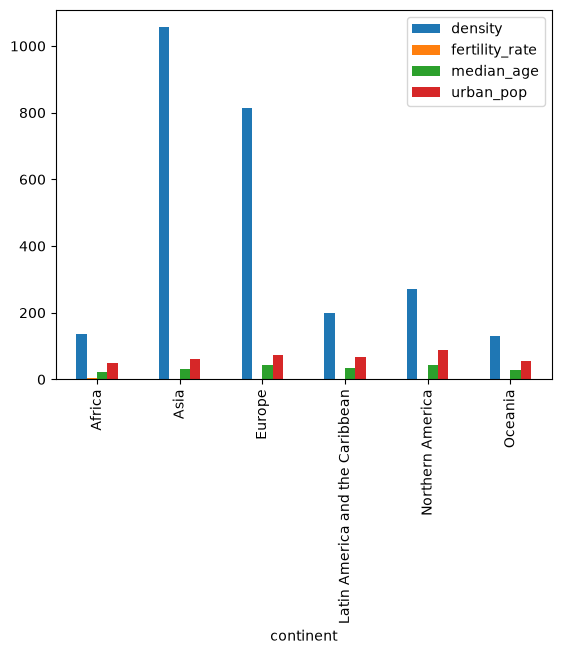

In [63]:
continent_averages.plot.bar()

# Section 2 - Fertility rate vs. median age

<Axes: xlabel='fertility_rate', ylabel='median_age'>

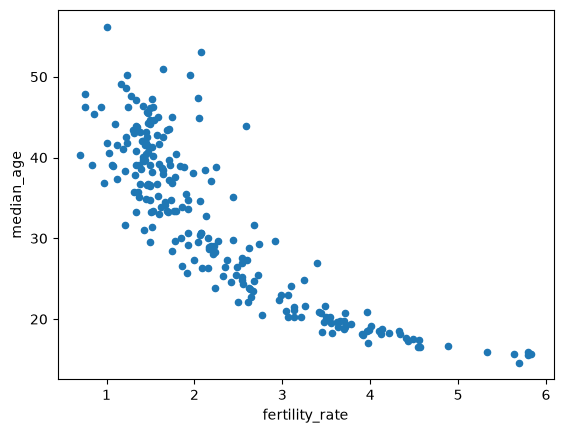

In [64]:
data.plot.scatter(x="fertility_rate", y="median_age")

#  Section 3 - Rankings 

In [65]:
data.sort_values("density", ascending=False)[["country", "density"]].head(10)

,country,density
215,Monaco,25562
166,"China, Macao SAR",24106
114,Singapore,8437
106,"China, Hong Kong SAR",7027
212,Gibraltar,4087
152,Bahrain,2205
172,Maldives,1772
171,Malta,1716
7,Bangladesh,1366
210,Sint Maarten,1307


In [66]:
data.sort_values("density")[["country", "density"]].head(10)

,country,density
206,Greenland,0
230,Falkland Islands,0
170,Western Sahara,2
132,Mongolia,2
54,Australia,4
37,Canada,4
104,Libya,4
177,Iceland,4
136,Namibia,4
164,Guyana,4


In [67]:
data.sort_values("urban_pop", ascending=False)[["country", "urban_pop"]].head(10)

,country,urban_pop
210,Sint Maarten,99.6
82,Belgium,99.0
190,Guam,98.9
166,"China, Macao SAR",98.3
170,Western Sahara,97.6
34,Argentina,96.5
135,Qatar,96.2
182,French Guiana,95.2
223,Nauru,93.8
11,Japan,93.4


In [68]:
data.sort_values("urban_pop")[["country", "urban_pop"]].head(10)

,country,urban_pop
229,Montserrat,11.7
88,Papua New Guinea,12.7
213,Liechtenstein,14.8
77,Burundi,15.4
187,Samoa,16.3
59,Sri Lanka,18.2
76,Rwanda,18.5
52,Niger,18.5
189,Saint Lucia,20.1
61,Malawi,20.2


In [69]:
data.sort_values("net_change", ascending=False)[["country", "net_change"]].head(10)

,country,net_change
0,India,12760051
5,Nigeria,4904050
4,Pakistan,4080237
14,DR Congo,3619689
9,Ethiopia,3430134
3,Indonesia,2165546
7,Bangladesh,2131145
19,Tanzania,2017915
2,United States,1759687
12,Egypt,1735180


In [70]:
data.sort_values("net_change")[["country", "net_change"]].head(10)

,country,net_change
1,China,-3182005
11,Japan,-675748
8,Russia,-602935
18,Germany,-430817
41,Poland,-297722
24,Italy,-220094
69,Romania,-108045
60,Taiwan,-101501
91,Czechia,-81458
30,South Korea,-66641


# Section 4: Population share by continent

In [72]:
continent_share = data.groupby("continent")["world_share"].sum()
continent_share

continent
Africa                             19.042662
Asia                               58.550500
Europe                              8.931726
Latin America and the Caribbean     8.119064
Northern America                    4.691516
Oceania                             0.562494
Name: world_share, dtype: float64

<Axes: xlabel='continent'>

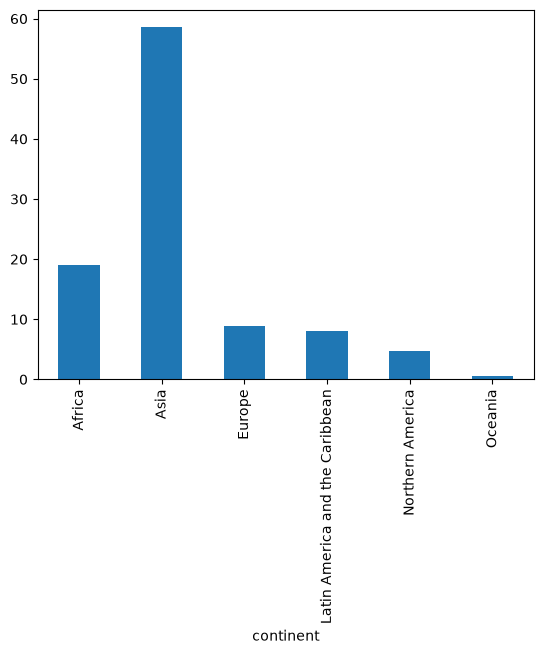

In [73]:
continent_share.plot.bar()

<Axes: xlabel='continent'>

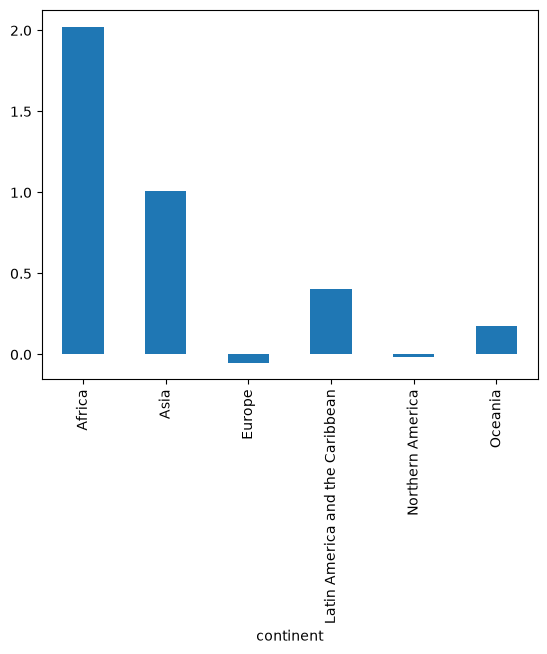

In [90]:
continent_growth = data.groupby("continent")["yearly_change"].mean()
continent_growth.plot.bar()

# Section 5 - Big but empty vs. small and crowded

<Axes: xlabel='land_area', ylabel='population'>

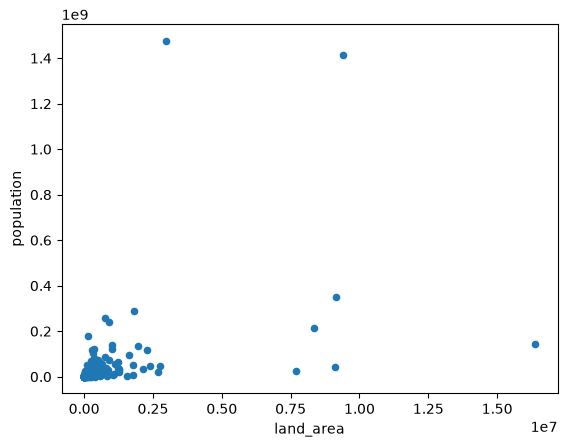

In [74]:
data.plot.scatter(x="land_area", y="population")

In [75]:
world_density = data["population"].sum() / data["land_area"].sum()
data["expected_population"] = data["land_area"] * world_density
data["size_population_ratio"] = data["population"] / data["expected_population"]
data[["country", "land_area", "population", "size_population_ratio"]].head()

,country,land_area,population,size_population_ratio
0,India,2973190,1476625576,7.785511
1,China,9388211,1412914089,2.359241
2,United States,9147420,349035494,0.598150
3,Indonesia,1811570,287886782,2.491185
4,Pakistan,770880,259299791,5.272964


In [76]:
data.sort_values("size_population_ratio", ascending=False)[["country", "land_area", "population", "size_population_ratio"]].head(10)

,country,land_area,population,size_population_ratio
233,Holy See,0,506,inf
215,Monaco,1,38087,597.057480
166,"China, Macao SAR",30,723188,377.893424
114,Singapore,700,5905748,132.256264
106,"China, Hong Kong SAR",1050,7378602,110.160060
212,Gibraltar,10,40867,64.063717
152,Bahrain,760,1675572,34.561205
172,Maldives,300,531517,27.773799
171,Malta,320,549011,26.894932
7,Bangladesh,130170,177818044,21.414321


In [77]:
data.sort_values("size_population_ratio")[["country", "land_area", "population", "size_population_ratio"]].head(10)

,country,land_area,population,size_population_ratio
206,Greenland,410450,55629,0.002125
230,Falkland Islands,12170,3465,0.004463
132,Mongolia,1553560,3556798,0.035890
170,Western Sahara,266000,610813,0.035997
54,Australia,7682300,27227096,0.055558
136,Namibia,823290,3153246,0.060041
182,French Guiana,82200,318872,0.060811
177,Iceland,100250,402329,0.062912
168,Suriname,156000,645256,0.064841
164,Guyana,196850,840890,0.066964


In [91]:
pop_by_continent = data.groupby("continent")["population"].sum()
land_by_continent = data.groupby("continent")["land_area"].sum()
true_density = pop_by_continent / land_by_continent
true_density

continent
Africa                              53.459240
Asia                               156.714042
Europe                              33.506049
Latin America and the Caribbean     33.374074
Northern America                    20.889767
Oceania                              5.552255
dtype: float64

In [92]:
avg_density = data.groupby("continent")["density"].mean()
avg_density

continent
Africa                              136.965517
Asia                               1055.843137
Europe                              813.510638
Latin America and the Caribbean     200.560000
Northern America                    271.000000
Oceania                             130.391304
Name: density, dtype: float64

In [93]:
density_gap = true_density - avg_density
density_gap.sort_values(ascending=False)

continent
Africa                             -83.506277
Oceania                           -124.839049
Latin America and the Caribbean   -167.185926
Northern America                  -250.110233
Europe                            -780.004589
Asia                              -899.129095
dtype: float64

# Section 6 - Demographic quadrants

In [94]:
def classify_fertility(fertility_rate):
    if fertility_rate < 2.1:
        return "low fertility"
    else:
        return "high fertility"

def classify_age(median_age):
    if median_age < 30:
        return "young"
    else:
        return "aging"

def classify_urban(urban_pop):
    if urban_pop < 50:
        return "rural"
    else:
        return "urban"

data["fertility_group"] = [classify_fertility(value) for value in data["fertility_rate"]]
data["age_group"] = [classify_age(value) for value in data["median_age"]]
data["urban_group"] = [classify_urban(value) for value in data["urban_pop"]]
data["quadrant"] = data["fertility_group"] + ", " + data["age_group"] + ", " + data["urban_group"]
data[["country", "fertility_rate", "median_age", "urban_pop", "quadrant"]].head()

,country,fertility_rate,median_age,urban_pop,quadrant
0,India,1.93,29.2,37.6,"low fertility, young, rural"
1,China,1.03,40.6,68.7,"low fertility, aging, urban"
2,United States,1.63,38.7,83.1,"low fertility, aging, urban"
3,Indonesia,2.08,30.7,60.3,"low fertility, aging, urban"
4,Pakistan,3.44,20.8,34.7,"high fertility, young, rural"


In [95]:
data.groupby("quadrant").size()

quadrant
high fertility, aging, rural      2
high fertility, aging, urban      6
high fertility, young, rural     48
high fertility, young, urban     45
low fertility, aging, rural      17
low fertility, aging, urban     107
low fertility, young, rural       5
low fertility, young, urban       4
dtype: int64

<Axes: xlabel='quadrant'>

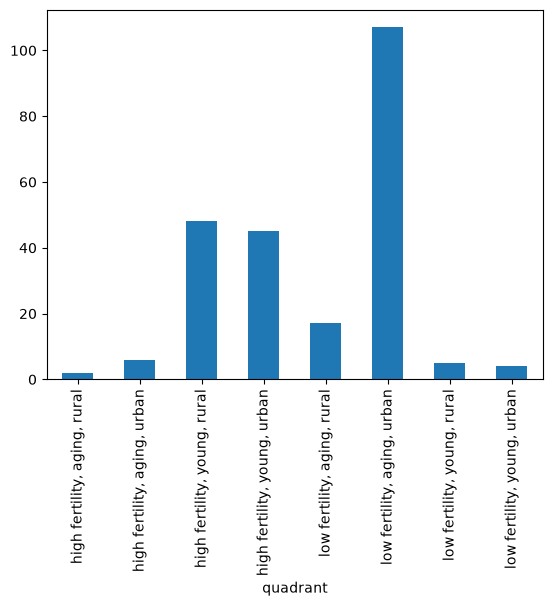

In [96]:
data.groupby("quadrant").size().plot.bar()

In [97]:
for quadrant in set(data["quadrant"]):
    print(quadrant)
    print(data[data["quadrant"] == quadrant].groupby("continent").size())

low fertility, aging, urban
continent
Africa                              1
Asia                               23
Europe                             45
Latin America and the Caribbean    26
Northern America                    5
Oceania                             7
dtype: int64
low fertility, young, rural
continent
Asia                               4
Latin America and the Caribbean    1
dtype: int64
high fertility, aging, urban
continent
Africa                             3
Latin America and the Caribbean    1
Oceania                            2
dtype: int64
low fertility, aging, rural
continent
Africa                             3
Asia                               4
Europe                             1
Latin America and the Caribbean    9
dtype: int64
high fertility, young, urban
continent
Africa                             19
Asia                               10
Latin America and the Caribbean     9
Oceania                             7
dtype: int64
high fertility, young, rural
c

In [98]:
below_replacement = data[data["fertility_group"] == "low fertility"]
below_replacement["world_share"].sum()

np.float64(72.5257881)

In [99]:
len(below_replacement)

133

# Section 7 - Migration-driven vs. birth-driven growth

In [100]:
def classify_growth(net_change, migrants):
    if migrants < 0:
        return "net exporter"
    natural_increase = net_change - migrants
    if migrants > natural_increase:
        return "migration-driven growth"
    else:
        return "birth-driven growth"

data["growth_type"] = [classify_growth(nc, mg) for nc, mg in zip(data["net_change"], data["migrants"])]
data[["country", "net_change", "migrants", "growth_type"]].head()

,country,net_change,migrants,growth_type
0,India,12760051,-440456,net exporter
1,China,-3182005,-232107,net exporter
2,United States,1759687,1177848,migration-driven growth
3,Indonesia,2165546,-39472,net exporter
4,Pakistan,4080237,-1144738,net exporter


In [101]:
data.groupby("growth_type").size()

growth_type
birth-driven growth         45
migration-driven growth     55
net exporter               134
dtype: int64

<Axes: xlabel='growth_type'>

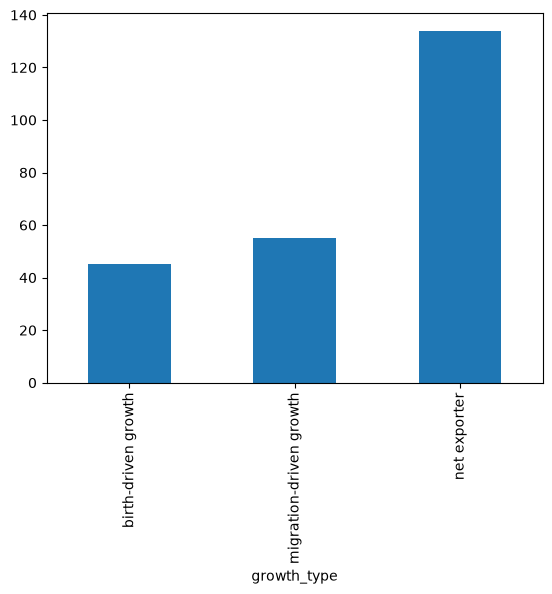

In [102]:
data.groupby("growth_type").size().plot.bar()

In [103]:
for growth_type in set(data["growth_type"]):
    print(growth_type)
    print(data[data["growth_type"] == growth_type].groupby("continent").size())

migration-driven growth
continent
Africa                              2
Asia                                7
Europe                             30
Latin America and the Caribbean    11
Northern America                    2
Oceania                             3
dtype: int64
birth-driven growth
continent
Africa                             14
Asia                               17
Europe                              2
Latin America and the Caribbean     9
Oceania                             3
dtype: int64
net exporter
continent
Africa                             42
Asia                               27
Europe                             15
Latin America and the Caribbean    30
Northern America                    3
Oceania                            17
dtype: int64


In [104]:
data.sort_values("migrants")[["country", "migrants", "net_change"]].head(10)

,country,migrants,net_change
4,Pakistan,-1144738,4080237
0,India,-440456,12760051
7,Bangladesh,-371398,2131145
51,Nepal,-292014,11292
1,China,-232107,-3182005
17,Turkey,-217896,240656
6,Brazil,-205642,750261
13,Philippines,-144275,937509
29,Uganda,-121799,1376575
63,Chad,-112304,556675


In [105]:
for group in set(data["fertility_group"]):
    print(group)
    print(data[data["fertility_group"] == group].groupby("growth_type").size())

high fertility
growth_type
birth-driven growth        22
migration-driven growth     4
net exporter               75
dtype: int64
low fertility
growth_type
birth-driven growth        23
migration-driven growth    51
net exporter               59
dtype: int64


In [110]:
data.groupby(["fertility_group", "growth_type"]).size()

fertility_group  growth_type            
high fertility   birth-driven growth        22
                 migration-driven growth     4
                 net exporter               75
low fertility    birth-driven growth        23
                 migration-driven growth    51
                 net exporter               59
dtype: int64

# Section 8 - Real growth vs. this year's snapshot

In [111]:
history = pd.read_csv("history.csv")
history["population"] = [int(clean_number(str(value))) for value in history["population"]]
history.head()

,country,year,population
0,India,2026,1476625576
1,India,2025,1463865525
2,India,2024,1450935791
3,India,2023,1438069596
4,India,2022,1425423212


In [112]:
recent = history[history["year"] == 2026][["country", "population"]]
past = history[history["year"] == 2000][["country", "population"]]
history_compare = pd.merge(recent, past, on="country", suffixes=("_2026", "_2000"))
history_compare.head()

,country,population_2026,population_2000
0,India,1476625576,1057922733
1,China,1412914089,1269581175
2,United States,349035494,281484131
3,Indonesia,287886782,216077790
4,Pakistan,259299791,154879127


In [113]:
years = 2026 - 2000
history_compare["actual_growth_pct"] = ((history_compare["population_2026"] / history_compare["population_2000"]) ** (1 / years) - 1) * 100
history_compare.head()

,country,population_2026,population_2000,actual_growth_pct
0,India,1476625576,1057922733,1.290768
1,China,1412914089,1269581175,0.412260
2,United States,349035494,281484131,0.830730
3,Indonesia,287886782,216077790,1.109684
4,Pakistan,259299791,154879127,2.001850


In [114]:
comparison = pd.merge(history_compare, data[["country", "yearly_change"]], on="country")
comparison[["country", "actual_growth_pct", "yearly_change"]]

,country,actual_growth_pct,yearly_change
0,India,1.290768,0.87
1,China,0.412260,-0.22
2,United States,0.830730,0.51
3,Indonesia,1.109684,0.76
4,Pakistan,2.001850,1.60
5,Nigeria,2.537063,2.06
6,Brazil,0.790686,0.35
7,Bangladesh,1.078339,1.21
8,Russia,-0.088083,-0.42
9,Ethiopia,2.819613,2.53


In [115]:
comparison["growth_difference"] = comparison["yearly_change"] - comparison["actual_growth_pct"]
comparison.sort_values("growth_difference", ascending=False)[["country", "actual_growth_pct", "yearly_change", "growth_difference"]]

,country,actual_growth_pct,yearly_change,growth_difference
7,Bangladesh,1.078339,1.21,0.131661
14,DR Congo,3.265094,3.21,-0.055094
19,Tanzania,2.928537,2.86,-0.068537
9,Ethiopia,2.819613,2.53,-0.289613
2,United States,0.830730,0.51,-0.320730
8,Russia,-0.088083,-0.42,-0.331917
3,Indonesia,1.109684,0.76,-0.349684
10,Mexico,1.156642,0.80,-0.356642
4,Pakistan,2.001850,1.60,-0.401850
11,Japan,-0.141765,-0.55,-0.408235


<Axes: xlabel='actual_growth_pct', ylabel='yearly_change'>

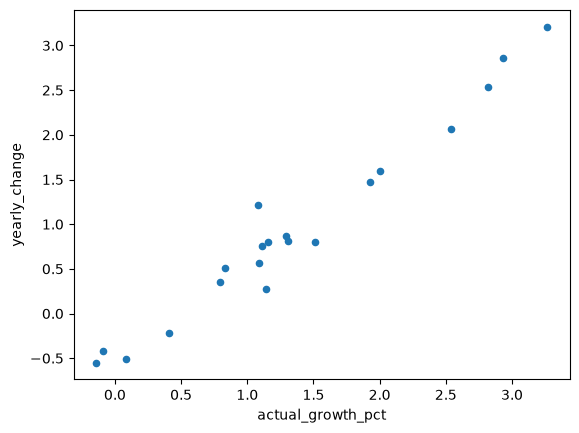

In [116]:
comparison.plot.scatter(x="actual_growth_pct", y="yearly_change")

In [117]:
comparison["doubling_time_years"] = 70 / comparison["actual_growth_pct"]
comparison[["country", "actual_growth_pct", "doubling_time_years"]]

,country,actual_growth_pct,doubling_time_years
0,India,1.290768,54.231290
1,China,0.412260,169.795793
2,United States,0.830730,84.263256
3,Indonesia,1.109684,63.081013
4,Pakistan,2.001850,34.967653
5,Nigeria,2.537063,27.590958
6,Brazil,0.790686,88.530691
7,Bangladesh,1.078339,64.914651
8,Russia,-0.088083,-794.706881
9,Ethiopia,2.819613,24.826099


In [119]:
comparison[comparison["actual_growth_pct"] > 0].sort_values("doubling_time_years")[["country", "actual_growth_pct", "doubling_time_years"]]

,country,actual_growth_pct,doubling_time_years
14,DR Congo,3.265094,21.438892
19,Tanzania,2.928537,23.902721
9,Ethiopia,2.819613,24.826099
5,Nigeria,2.537063,27.590958
4,Pakistan,2.001850,34.967653
12,Egypt,1.928886,36.290380
13,Philippines,1.515265,46.196549
16,Iran,1.310169,53.428240
0,India,1.290768,54.231290
10,Mexico,1.156642,60.520003


In [120]:
comparison[comparison["actual_growth_pct"] <= 0][["country", "actual_growth_pct"]]

,country,actual_growth_pct
8,Russia,-0.088083
11,Japan,-0.141765
